In [7]:
import os
import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [8]:
IMG_SIZE = (64, 64)
DATASET_PATH = "images"

X = []
y = []

for class_name in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, class_name)
    if not os.path.isdir(class_path):
        continue

    for root, _, files in os.walk(class_path):
        for file in files:
            if file.lower().endswith((".jpg", ".jpeg", ".png")):
                img_path = os.path.join(root, file)
                try:
                    img = Image.open(img_path).convert("RGB")
                    img = img.resize(IMG_SIZE)
                    X.append(np.array(img))
                    y.append(class_name)
                except:
                    pass

X = np.array(X).astype("float32") / 255.0
y = np.array(y)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (12000, 64, 64, 3)
Test shape: (3000, 64, 64, 3)


In [9]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [10]:
X_train_flat = X_train.reshape(X_train.shape[0], -1) / 255.0
X_test_flat = X_test.reshape(X_test.shape[0], -1) / 255.0

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_flat, y_train)
y_pred_rf = rf.predict(X_test_flat)

rf_acc = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_acc)
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

Random Forest Accuracy: 0.6343333333333333
                            precision    recall  f1-score   support

              aerosol_cans       0.85      0.69      0.76       100
        aluminum_food_cans       0.45      0.41      0.43       100
        aluminum_soda_cans       0.65      0.64      0.64       100
           cardboard_boxes       0.50      0.55      0.52       100
       cardboard_packaging       0.44      0.52      0.48       100
                  clothing       0.49      0.39      0.44       100
            coffee_grounds       0.57      0.84      0.68       100
disposable_plastic_cutlery       0.73      0.69      0.71       100
                 eggshells       0.52      0.65      0.58       100
                food_waste       0.65      0.83      0.73       100
    glass_beverage_bottles       0.69      0.69      0.69       100
 glass_cosmetic_containers       0.62      0.74      0.68       100
           glass_food_jars       0.70      0.64      0.67       100
    

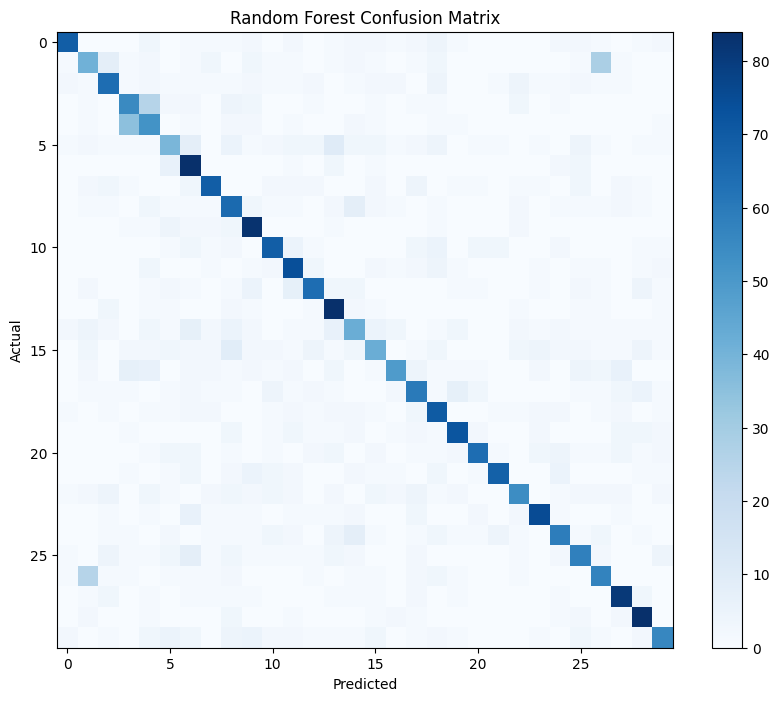

In [12]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [61]:
num_classes = len(np.unique(y_train))

model = models.Sequential([
    layers.Input(shape=(64, 64, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)                   │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_18 (MaxPooling2D)      │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_19 (Conv2D)                   │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_19 (MaxPooling2D)      │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_20 (Conv2D)                   │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_20 (MaxPooling2D)      │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_6 (Flatten)                  │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 128)                 │         589,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 30)                  │           3,870 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 687,070 (2.62 MB)

 Trainable params: 687,070 (2.62 MB)

 Non-trainable params: 0 (0.00 B)

In [62]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [63]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.1483 - loss: 3.0345 - val_accuracy: 0.2387 - val_loss: 2.6590
Epoch 2/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.3298 - loss: 2.3746 - val_accuracy: 0.3500 - val_loss: 2.2934
Epoch 3/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.4441 - loss: 1.9568 - val_accuracy: 0.4283 - val_loss: 2.0730
Epoch 4/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5448 - loss: 1.5937 - val_accuracy: 0.4921 - val_loss: 1.8578
Epoch 5/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6425 - loss: 1.2358 - val_accuracy: 0.5142 - val_loss: 1.8890
Epoch 6/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7272 - loss: 0.9308 - val_accuracy: 0.5529 - val_loss: 1.8669
Epoch 7/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8004 - loss: 0.6756 - val_accuracy: 0.5733 - val_loss: 1.9235
Epoch 8/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8421 - loss: 0.5209 - val_accu

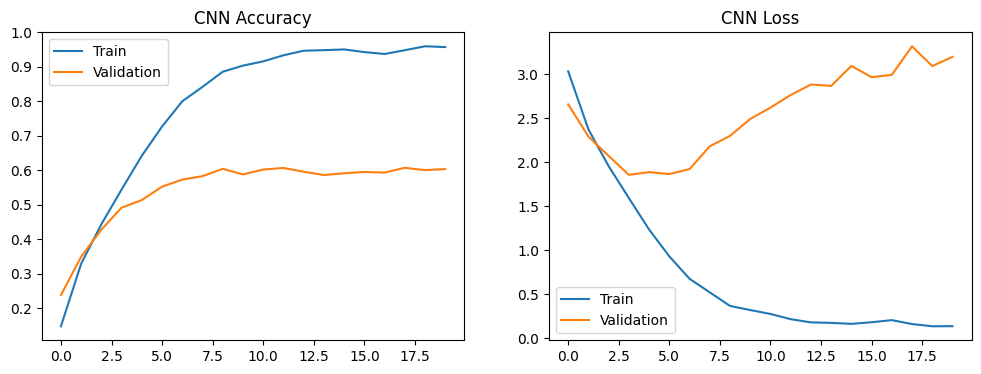

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("CNN Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("CNN Loss")
plt.legend()

plt.show()

In [65]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"CNN Test Accuracy: {test_acc:.4f}")

CNN Test Accuracy: 0.5880


94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


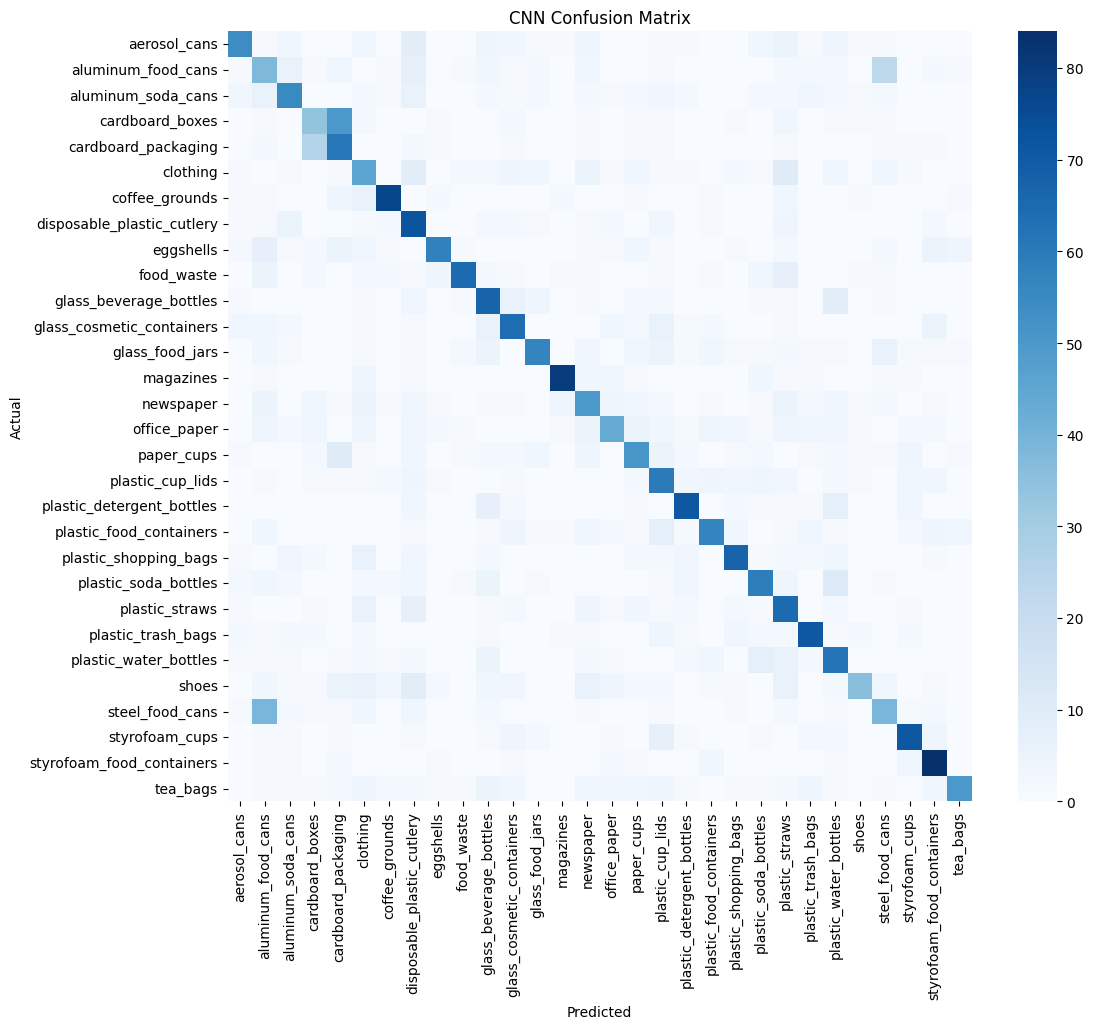

In [66]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    fmt="d"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")
plt.show()


In [67]:
print("CNN Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

CNN Classification Report:
                            precision    recall  f1-score   support

              aerosol_cans       0.71      0.54      0.61       100
        aluminum_food_cans       0.29      0.38      0.33       100
        aluminum_soda_cans       0.61      0.55      0.58       100
           cardboard_boxes       0.41      0.34      0.37       100
       cardboard_packaging       0.41      0.61      0.49       100
                  clothing       0.40      0.46      0.43       100
            coffee_grounds       0.81      0.77      0.79       100
disposable_plastic_cutlery       0.45      0.72      0.56       100
                 eggshells       0.78      0.58      0.67       100
                food_waste       0.86      0.65      0.74       100
    glass_beverage_bottles       0.52      0.67      0.59       100
 glass_cosmetic_containers       0.59      0.64      0.62       100
           glass_food_jars       0.74      0.57      0.64       100
                 mag

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt = DecisionTreeClassifier(
    max_depth=20,
    random_state=42
)

dt.fit(X_train_flat, y_train)

y_pred_dt = dt.predict(X_test_flat)

dt_acc = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_acc)
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(10, 8))
plt.imshow(cm_dt, cmap="Blues")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [ ]:
DISPOSAL_MAP = {
    "Plastic": [
        "plastic_cup_lids", "plastic_detergent_bottles", "plastic_food_containers",
        "plastic_shopping_bags", "plastic_soda_bottles", "plastic_straws",
        "plastic_trash_bags", "plastic_water_bottles",
        "styrofoam_cups", "styrofoam_food_containers",
        "disposable_plastic_cutlery"
    ],
    "Paper": [
        "cardboard_boxes", "cardboard_packaging", "magazines",
        "newspaper", "office_paper", "paper_cups"
    ],
    "Glass": [
        "glass_beverage_bottles", "glass_cosmetic_containers", "glass_food_jars"
    ],
    "Metal": [
        "aerosol_cans", "aluminum_food_cans", "aluminum_soda_cans", "steel_food_cans"
    ],
    "Organic": [
        "food_waste", "coffee_grounds", "eggshells", "tea_bags"
    ],
    "Trash": [
        "clothing", "shoes"
    ]
}

In [23]:
def decide_disposal(predicted_class):
    for bin_name, class_list in DISPOSAL_MAP.items():
        if predicted_class in class_list:
            return bin_name
    return "Trash"

In [24]:
sample_indices = range(10)

for i in sample_indices:
    predicted_label = le.inverse_transform([y_pred_rf[i]])[0]
    disposal_bin = decide_disposal(predicted_label)

    print(f"Predicted class: {predicted_label:30s} → Disposal bin: {disposal_bin}")

Predicted class: magazines                      → Disposal bin: Paper
Predicted class: plastic_food_containers        → Disposal bin: Plastic
Predicted class: plastic_detergent_bottles      → Disposal bin: Plastic
Predicted class: cardboard_boxes                → Disposal bin: Paper
Predicted class: glass_beverage_bottles         → Disposal bin: Glass
Predicted class: plastic_soda_bottles           → Disposal bin: Plastic
Predicted class: plastic_trash_bags             → Disposal bin: Plastic
Predicted class: steel_food_cans                → Disposal bin: Metal
Predicted class: plastic_cup_lids               → Disposal bin: Plastic
Predicted class: plastic_soda_bottles           → Disposal bin: Plastic
